# １章３節７項　ベースライン

## 概要
干渉解析の時間・垂直ベースラインの可視化や、位相の処理です。

## 使用データ

| 項目 | 情報 |
| ---- | ---- |
| 衛星 | Sentinel-1 |
| 観測シーンID　| メイン:`S1A_IW_SLC__1SDV_20230729T204331_20230729T204358_049643_05F833_0EF3`　|
| データリンク | Baseline:[ASF](https://search.asf.alaska.edu/#/?searchType=Baseline%20Search&master=S1A_IW_SLC__1SDV_20230729T204331_20230729T204358_049643_05F833_0EF3&resultsLoaded=true&granule=S1A_IW_SLC__1SDV_20230729T204331_20230729T204358_049643_05F833_0EF3-SLC&perp=-242.29to225&temporal=-2438.02to384) , SBAS: [ASF](https://search.asf.alaska.edu/#/?searchType=SBAS%20Search&master=S1A_IW_SLC__1SDV_20230729T204331_20230729T204358_049643_05F833_0EF3&resultsLoaded=true&granule=S1A_IW_SLC__1SSV_20170125T204301_20170125T204328_014993_0187B6_4FB8-SLC&perp=800to&temporal=1to24&selectedPair=S1A_IW_SLC__1SSV_20141125T204235_20141125T204302_003443_004066_3494-SLC,S1A_IW_SLC__1SSV_20141207T204234_20141207T204301_003618_004478_5D9A-SLC) |
| 画像クレジット| © ESA Copernicus Sentinel-1 |

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import tifffile
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
from tqdm import tqdm
import pandas as pd

In [ ]:
PATH_OUTPUT = 'output/1_5_9/'
os.makedirs(PATH_OUTPUT, exist_ok=True)

## ベースライン

In [3]:
PATH_CSV = '../data/baseline/baselines.csv'

df = pd.read_csv(PATH_CSV)
print(df.columns)
df.head(3)

Index(['Granule Name', 'Platform', 'Sensor', 'Beam Mode',
       'Beam Mode Description', 'Orbit', 'Path Number', 'Frame Number',
       'Acquisition Date', 'Processing Date', 'Processing Level', 'Start Time',
       'End Time', 'Center Lat', 'Center Lon', 'Near Start Lat',
       'Near Start Lon', 'Far Start Lat', 'Far Start Lon', 'Near End Lat',
       'Near End Lon', 'Far End Lat', 'Far End Lon', 'Faraday Rotation',
       'Ascending or Descending?', 'URL', 'Size (MB)', 'Off Nadir Angle',
       'Stack Size', 'Doppler', 'GroupID', 'Pointing Angle',
       'TemporalBaseline', 'PerpendicularBaseline', 'relativeBurstID',
       'absoluteBurstID', 'fullBurstID', 'burstIndex', 'azimuthTime',
       'azimuthAnxTime', 'samplesPerBurst', 'subswath'],
      dtype='object')


,Granule Name,Platform,Sensor,Beam Mode,Beam Mode Description,Orbit,Path Number,Frame Number,Acquisition Date,Processing Date,...,TemporalBaseline,PerpendicularBaseline,relativeBurstID,absoluteBurstID,fullBurstID,burstIndex,azimuthTime,azimuthAnxTime,samplesPerBurst,subswath
0,S1A_IW_SLC__1SSV_20170125T204301_20170125T2043...,Sentinel-1A,C-SAR,IW,"Interferometric Wide. 250 km swath, 5 m x 20 m...",14993,46,473,2017-01-25T20:43:28.395411Z,2017-01-25T20:43:01.432679Z,...,-2376,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,S1A_IW_SLC__1SSV_20170125T204236_20170125T2043...,Sentinel-1A,C-SAR,IW,"Interferometric Wide. 250 km swath, 5 m x 20 m...",14993,46,468,2017-01-25T20:43:03.566346Z,2017-01-25T20:42:36.607725Z,...,-2376,-33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,S1A_IW_SLC__1SSV_20170101T204302_20170101T2043...,Sentinel-1A,C-SAR,IW,"Interferometric Wide. 250 km swath, 5 m x 20 m...",14643,46,473,2017-01-01T20:43:30.045982Z,2017-01-01T20:43:02.129472Z,...,-2400,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
select_columns = [
    'Granule Name', 'Orbit', 
    'Path Number', 'Frame Number', 'Ascending or Descending?',
    'TemporalBaseline', 'PerpendicularBaseline',
]

df = df[select_columns]
df.head(3)

,Granule Name,Orbit,Path Number,Frame Number,Ascending or Descending?,TemporalBaseline,PerpendicularBaseline
0,S1A_IW_SLC__1SSV_20170125T204301_20170125T2043...,14993,46,473,DESCENDING,-2376,7
1,S1A_IW_SLC__1SSV_20170125T204236_20170125T2043...,14993,46,468,DESCENDING,-2376,-33
2,S1A_IW_SLC__1SSV_20170101T204302_20170101T2043...,14643,46,473,DESCENDING,-2400,36


In [5]:
# search
Path_Number = 46
Frame_Number = 470
asc_des = 'DESCENDING'

df_search = df[(df['Path Number'] == Path_Number) & (df['Frame Number'] == Frame_Number) & (df['Ascending or Descending?'] == asc_des)]
print("Num Scene", len(df_search))

Num Scene 102


In [6]:
df_center = df_search[df_search['TemporalBaseline'] == 0]
df_center.head()

,Granule Name,Orbit,Path Number,Frame Number,Ascending or Descending?,TemporalBaseline,PerpendicularBaseline
80,S1A_IW_SLC__1SDV_20230729T204331_20230729T2043...,49643,46,470,DESCENDING,0,0


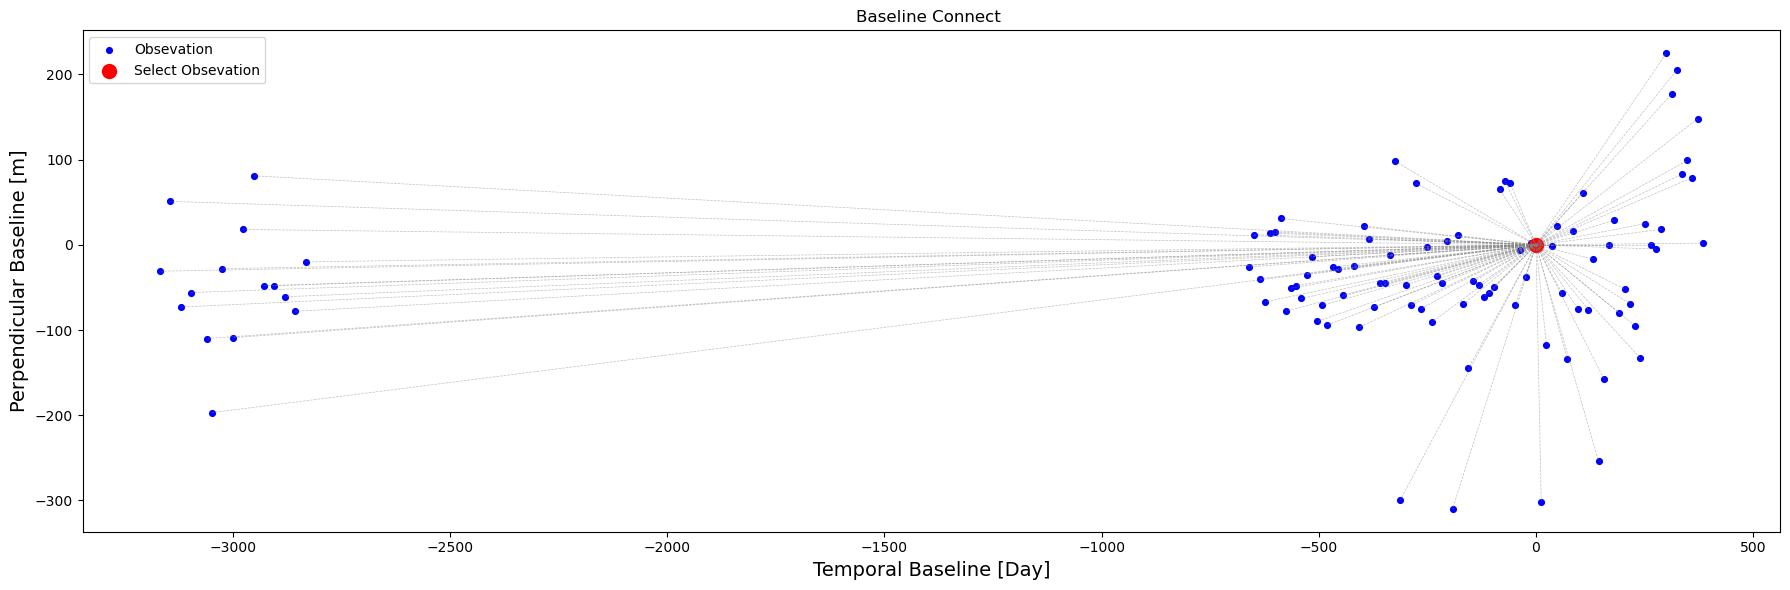

In [7]:
y = df_search['PerpendicularBaseline'].reset_index(drop=True)
x = df_search['TemporalBaseline'].reset_index(drop=True)

# プロットの設定
plt.figure(figsize=(18, 6))
plt.title(f'Baseline Connect ')

point_y, point_x = df_center['PerpendicularBaseline'].values[0], df_center['TemporalBaseline'].values[0]
# 1点から全ての点への線を引く
for i in range(len(x)):
    plt.plot([point_x, x[i]], [point_y, y[i]], color='gray', linestyle='--', alpha=0.5, linewidth=0.5)

plt.scatter(x, y, color='blue', label='Observation', s=17)
plt.scatter(point_x, point_y, color='red', label='Select Observation', s=100)  # 1点を赤色で表示
plt.legend()
plt.ylabel(f'Perpendicular Baseline [m]', fontsize=14)
plt.xlabel(f'Temporal Baseline [Day]', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'baseline_connect.png'))
plt.show();plt.clf();plt.close()

In [8]:
# re:search
Path_Number = 46
Frame_Number = 470
asc_des = 'DESCENDING'

max_perpendicular_baseline = 50
min_perpendicular_baseline = -max_perpendicular_baseline

max_temporal_baseline = 500
min_temporal_baseline = -max_temporal_baseline

df_search = df[(df['Path Number'] == Path_Number) & (df['Frame Number'] == Frame_Number) & (df['Ascending or Descending?'] == asc_des)]
df_search = df_search[(df_search['PerpendicularBaseline'] < max_perpendicular_baseline) & (df_search['PerpendicularBaseline'] > min_perpendicular_baseline)]
df_search = df_search[(df_search['TemporalBaseline'] < max_temporal_baseline) & (df_search['TemporalBaseline'] > min_temporal_baseline)]
print("Num Scene", len(df_search))

Num Scene 32


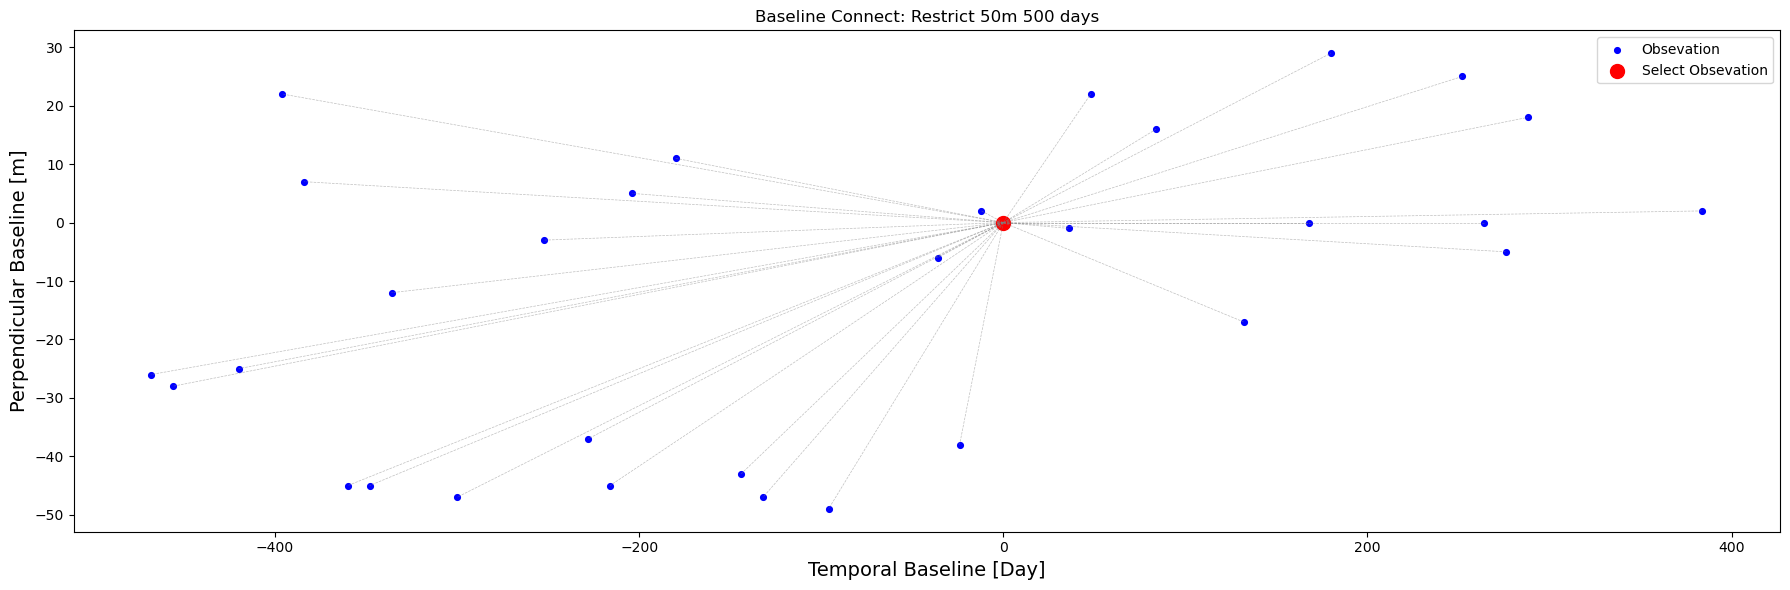

In [9]:
y = df_search['PerpendicularBaseline'].reset_index(drop=True)
x = df_search['TemporalBaseline'].reset_index(drop=True)

# プロットの設定
plt.figure(figsize=(18, 6))
plt.title(f'Baseline Connect: Restrict {max_perpendicular_baseline}m {max_temporal_baseline} days')

point_y, point_x = df_center['PerpendicularBaseline'].values[0], df_center['TemporalBaseline'].values[0]

# 1点から全ての点への線を引く
for i in range(len(x)):
    plt.plot([point_x, x[i]], [point_y, y[i]], color='gray', linestyle='--', alpha=0.5, linewidth=0.5)

plt.scatter(x, y, color='blue', label='Observation', s=17)
plt.scatter(point_x, point_y, color='red', label='Select Observation', s=100)  # 1点を赤色で表示
plt.legend()
plt.ylabel(f'Perpendicular Baseline [m]', fontsize=14)
plt.xlabel(f'Temporal Baseline [Day]', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'baseline_connect_p{max_perpendicular_baseline}d{max_temporal_baseline}.png'))
plt.show();plt.clf();plt.close()

In [10]:
# re:search
Path_Number = 46
Frame_Number = 470
asc_des = 'DESCENDING'

max_perpendicular_baseline = 150
min_perpendicular_baseline = -max_perpendicular_baseline

max_temporal_baseline = 600
min_temporal_baseline = -max_temporal_baseline

df_search = df[(df['Path Number'] == Path_Number) & (df['Frame Number'] == Frame_Number) & (df['Ascending or Descending?'] == asc_des)]
df_search = df_search[(df_search['PerpendicularBaseline'] < max_perpendicular_baseline) & (df_search['PerpendicularBaseline'] > min_perpendicular_baseline)]
df_search = df_search[(df_search['TemporalBaseline'] < max_temporal_baseline) & (df_search['TemporalBaseline'] > min_temporal_baseline)]
print("Num Scene", len(df_search))

Num Scene 73


## SBAS

In [11]:
PATH_CSV_PIAR = '../data/baseline/sbas-pairs.csv'

df_pair = pd.read_csv(PATH_CSV_PIAR)
df_pair.rename(columns={'Reference': 'Granule Name'}, inplace=True)
df_pair.head(4)

,Granule Name,Reference URL,Secondary,Secondary URL,Pair Perpendicular Baseline (meters),Pair Temporal Baseline (days)
0,S1A_IW_SLC__1SSV_20141125T204235_20141125T2043...,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,S1A_IW_SLC__1SSV_20141207T204234_20141207T2043...,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,61,12
1,S1A_IW_SLC__1SSV_20141125T204235_20141125T2043...,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,S1A_IW_SLC__1SSV_20141219T204235_20141219T2043...,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,82,24
2,S1A_IW_SLC__1SSV_20141125T204235_20141125T2043...,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,S1A_IW_SLC__1SSV_20141231T204233_20141231T2043...,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,4,36
3,S1A_IW_SLC__1SSV_20141125T204235_20141125T2043...,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,S1A_IW_SLC__1SSV_20150112T204234_20150112T2043...,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,42,48


In [12]:
df_search_pair = df_search.join(df_pair.set_index('Granule Name'), on='Granule Name')
print("Num Pair", len(df_search_pair))
df_search_pair.head(3)

Num Pair 346


,Granule Name,Orbit,Path Number,Frame Number,Ascending or Descending?,TemporalBaseline,PerpendicularBaseline,Reference URL,Secondary,Secondary URL,Pair Perpendicular Baseline (meters),Pair Temporal Baseline (days)
48,S1A_IW_SLC__1SDV_20240816T204328_20240816T2043...,55243,46,470,DESCENDING,384,2,NaN,NaN,NaN,NaN,NaN
49,S1A_IW_SLC__1SDV_20240804T204328_20240804T2043...,55068,46,470,DESCENDING,372,148,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,S1A_IW_SLC__1SDV_20240816T204328_20240816T2043...,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,146.0,12.0
50,S1A_IW_SLC__1SDV_20240723T204328_20240723T2043...,54893,46,470,DESCENDING,360,79,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,S1A_IW_SLC__1SDV_20240804T204328_20240804T2043...,https://datapool.asf.alaska.edu/SLC/SA/S1A_IW_...,69.0,12.0


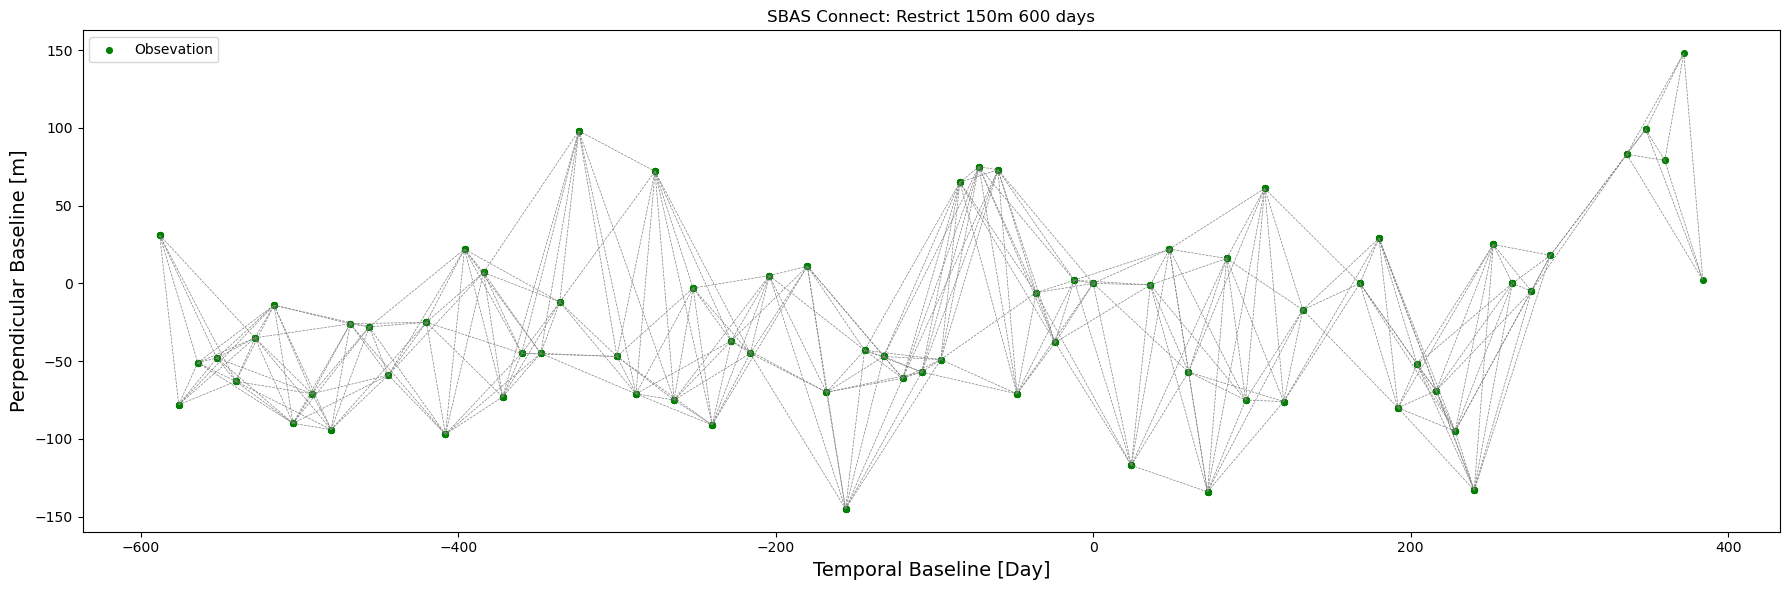

In [13]:
y = df_search_pair['PerpendicularBaseline'].reset_index(drop=True)
x = df_search_pair['TemporalBaseline'].reset_index(drop=True)

plt.figure(figsize=(18, 6))
plt.title(f'SBAS Connect: Restrict {max_perpendicular_baseline}m {max_temporal_baseline} days')
for idx, row in df_search_pair.iterrows():
    point_y, point_x = row['PerpendicularBaseline'], row['TemporalBaseline']
    secondary_id = row[' Secondary']
    row_secondary = df_search_pair[df_search_pair['Granule Name'] == secondary_id]
    if len(row_secondary) > 0:
        x_secondary, y_secondary = row_secondary['TemporalBaseline'].iloc[0], row_secondary['PerpendicularBaseline'].iloc[0]
        plt.plot([point_x, x_secondary], [point_y, y_secondary], color='gray', linestyle='--',linewidth=0.5)

plt.scatter(x, y, color='g', label='Observation', s=17)
plt.legend()
plt.ylabel(f'Perpendicular Baseline [m]', fontsize=14)
plt.xlabel(f'Temporal Baseline [Day]', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'sbas_connect_p{max_perpendicular_baseline}d{max_temporal_baseline}.png'))
plt.show();plt.clf();plt.close()

## 特異点分解処理


観測回数 t:
 38
干渉ペア数: 431
観測時刻 t:
 [ 1.   3.   6.  10.  12.  11.   4.6  4.7  9.8  4.9  5.   2.1  1.7  9.
  7.5  7.   3.6  3.7  3.8  3.9  4.   2.   1.9  5.5  9.5  8.   4.1  4.2
  6.3  4.4  4.5  8.5  9.4  3.1  3.2  7.3  3.4  3.5]

干渉位相差 φ:
 [ 1.00226776e-12 -1.16294833e+00 -1.15445773e-12 -6.47881064e-13
  1.15192990e-01  2.30385979e-01 -5.00000000e+00 -4.96933166e+00
  3.06432266e+00 -1.06615019e+00  1.27122639e+00  5.00000000e+00
 -3.67342694e+00 -6.83499009e-02 -1.44114930e-01 -1.13173611e+00
 -3.31948319e+00  1.76145617e+00  3.13358914e-02  3.51491878e-01
  6.86397847e-01 -1.41314352e-01 -9.79518974e-02 -1.09098259e-01
 -2.86717719e-02  5.60329987e-02 -9.82108707e-02 -4.18489261e-02
 -1.45658275e-01 -1.36946400e-01  1.46998928e-01 -1.58346593e-02
  7.25326271e-02  4.13348384e-03  9.01327976e-02  4.03967085e-02
  3.70082315e-03]


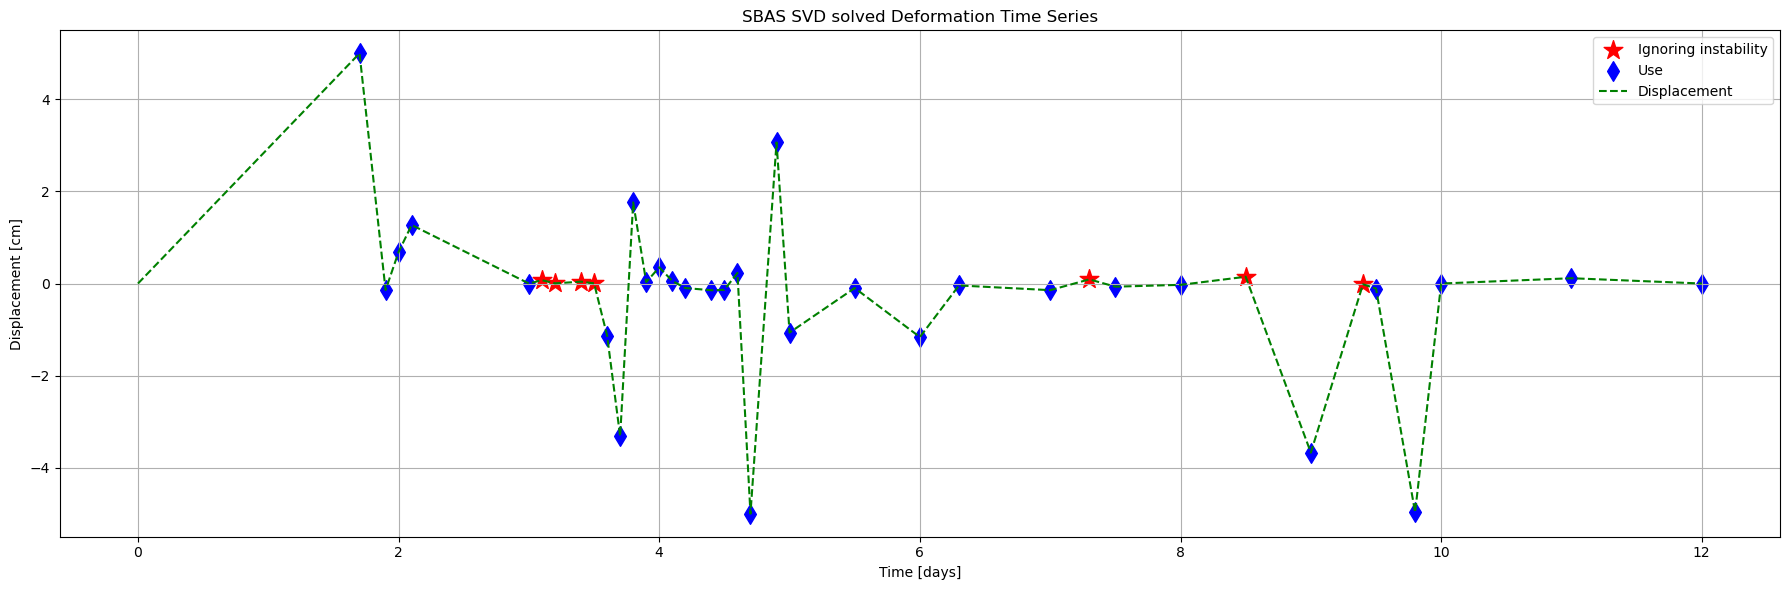

In [ ]:
np.random.seed(202509)

t = np.array([1, 3, 6, 10, 12, 11,
              4.6, 4.7, 9.8, 4.9, 5.0,
              2.1, 1.7, 9, 7.5, 7,
              3.6, 3.7, 3.8, 3.9, 4.0,
              2, 1.9, 5.5, 9.5, 8,
              4.1, 4.2, 6.3, 4.4, 4.5,
              8.5, 9.4,
              3.1, 3.2, 7.3, 3.4, 3.5,])
print("観測回数 t:\n", len(t))

threshold_time = 4
n_pair = 300

# 干渉ペアを作成 (i < j の組み合わせ)
pairs = [(i, j) for i in range(len(t)) for j in range(i + 1, len(t)-1) 
         if abs(t[i] - t[j]) < threshold_time
         ]
print("干渉ペア数:", len(pairs))
pairs = np.array(pairs)
np.random.shuffle(pairs)
pairs_random = pairs[:n_pair]

# 観測行列 A を作成 (ペア数 x 観測時刻数)
A = np.zeros((len(pairs), len(t)-1))

# A の行を干渉ペア (ti, tj) に従って設定
for k, (i, j) in enumerate(pairs_random):
    A[i, j] = j-i  # tj - ti

# 干渉位相差 φ をランダムに生成
d = np.random.rand(len(pairs))

# 特異値分解 (SVD) を用いて擬似逆行列 A^+ を求める
U, S, Vt = np.linalg.svd(A, full_matrices=False)

S_inv = np.diag(1 / S)
threshold = 1e-2
is_singular = S < threshold

S_inv_reduced = np.where(is_singular, 0, S_inv)
A_plus_reduced = Vt.T @ S_inv_reduced @ U.T

velocity = A_plus_reduced @ d
clip_velocity_value = 5.0
velocity = np.clip(velocity, -clip_velocity_value, clip_velocity_value)

print("観測時刻 t:\n", t)
print("\n干渉位相差 φ:\n", velocity)

velocity_ignore = velocity[is_singular]
t_ignore = t[1:][is_singular]

velocity_use = velocity[~is_singular]
t_use = t[1:][~is_singular]

t_v_dict = {_t:velocity[k] for (k, _t) in enumerate(t[1:])}
t_v_dict[0] = 0 # 初期値は変動なし

# sort
t_v_dict = dict(sorted(t_v_dict.items(), key=lambda x:x[0]))

plt.figure(figsize=(18, 6), dpi=100, facecolor='w', edgecolor='k')
plt.scatter(t_ignore, velocity_ignore ,color='red', label='Ignoring instability', s=200, marker='*')
plt.scatter(t_use, velocity_use,color='blue', label='Use', s=100, marker='d')
plt.title('SBAS SVD solved Deformation Time Series')
plt.plot(t_v_dict.keys(), t_v_dict.values(), '--', label='Displacement', color='green')
plt.xlabel('Time [days]')
plt.ylabel('Displacement [cm]')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'sbas_svd_solver.png'))
plt.show();plt.clf();plt.close()


観測回数 t:
 43
干渉ペア数: 452
観測時刻 t:
 [ 1.    3.    6.   10.   12.   11.    4.6   4.7   9.8   4.9   5.    2.1
  1.7   9.    7.5   7.    3.6   3.7   3.8   3.9   4.    2.    1.9   5.5
  9.5   8.    4.1   4.2   6.3   4.4   4.5   8.5   9.4   2.6   1.97  5.4
  9.    8.1   3.1   3.2   7.3   3.4   3.5 ]

干渉位相差 φ:
 [-8.58003190e-14  1.39064837e-14  4.84341092e-14 -1.12011831e-14
  3.97903363e-14 -5.52006677e-14  3.47121405e-14  1.83030194e-02
 -2.69831189e+00 -2.31344141e+00  8.61014348e-16  5.08609174e-01
  4.10579400e-01 -7.75976630e-15  5.93251702e-01 -1.68477599e+00
  1.11519092e+00  6.56147707e-15  3.29359208e-01 -2.75629019e-01
  1.23137530e+00 -3.27491553e-01 -2.76870032e-01  3.17091064e-01
  5.67878378e-02 -1.01940118e-01 -1.47995276e-01 -3.16859201e-01
 -1.76321149e-02  1.99838483e-01  1.05649101e-01  0.00000000e+00
  3.79062522e-02 -2.15352993e-03  4.57336996e-02  2.93642264e-02
  1.92420708e-01  1.41540021e-01  1.64715879e-01  9.19360386e-02
  3.15959506e-02  2.72439558e-01]


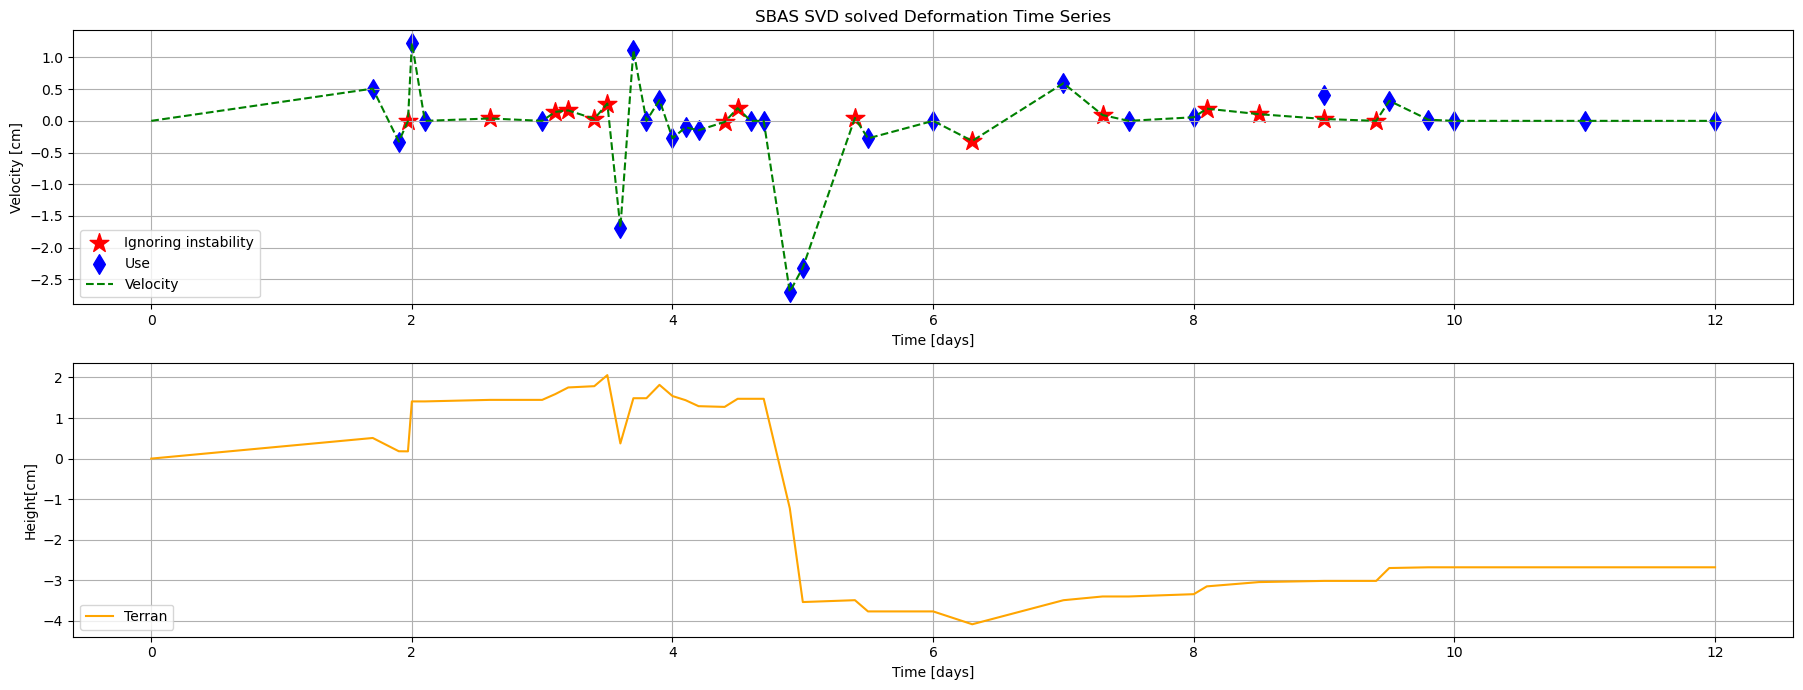

In [15]:
np.random.seed(202509)

t = np.array([1, 3, 6, 10, 12, 11,
              4.6, 4.7, 9.8, 4.9, 5.0,
              2.1, 1.7, 9, 7.5, 7,
              3.6, 3.7, 3.8, 3.9, 4.0,
              2, 1.9, 
              5.5, 9.5, 8,
              4.1, 4.2, 6.3, 4.4, 4.5,
              8.5, 9.4,
              2.6, 1.97, 5.4, 9., 8.1,
              3.1, 3.2, 7.3, 3.4, 3.5,
              ])

print("観測回数 t:\n", len(t))

threshold_time = 3
n_pair = 100

# 干渉ペアを作成 (i < j の組み合わせ)
pairs = [(i, j) for i in range(len(t)) for j in range(i + 1, len(t)-1) 
         if abs(t[i] - t[j]) < threshold_time
         ]
print("干渉ペア数:", len(pairs))
# ランダムサンプル n個のペアを取得
pairs = np.array(pairs)
np.random.shuffle(pairs)
pairs_random = pairs[:n_pair]

# 観測行列 A を作成 (ペア数 x 観測時刻数)
A = np.zeros((len(pairs), len(t)-1))

# A の行を干渉ペア (ti, tj) に従って設定
for k, (i, j) in enumerate(pairs_random):
    A[i, j] = j-i  # tj - ti
    
slope = np.linspace(0, 17, len(pairs))

# 干渉位相差 φ をランダムに生成
d = np.random.rand(len(pairs)) + slope

# 特異値分解 (SVD) を用いて擬似逆行列 A^+ を求める
U, S, Vt = np.linalg.svd(A, full_matrices=False)

S_inv = np.diag(1 / S)
threshold = 1e-2
is_singular = S < threshold

S_inv_reduced = np.where(is_singular, 0, S_inv)
A_plus_reduced = Vt.T @ S_inv_reduced @ U.T

velocity = A_plus_reduced @ d
clip_velocity_value = 23.4 # L Band
velocity = np.clip(velocity, -clip_velocity_value, clip_velocity_value)

print("観測時刻 t:\n", t)
# print("\n干渉ペア:\n", pairs)
# print("\n観測行列 A:\n", A)
print("\n干渉位相差 φ:\n", velocity)
# print("\n変位ベクトル d:\n", d)

velocity_ignore = velocity[is_singular]
t_ignore = t[1:][is_singular]

velocity_use = velocity[~is_singular]
t_use = t[1:][~is_singular]
    
t_v_dict = {_t:velocity[k] for (k, _t) in enumerate(t[1:])}
t_v_dict[0] = 0 # 初期値は変動なし
t_s_dict = {_t:is_singular[k] for (k, _t) in enumerate(t[1:])}

# sort
t_v_dict = dict(sorted(t_v_dict.items(), key=lambda x:x[0]))
t_s_dict = dict(sorted(t_s_dict.items(), key=lambda x:x[0]))


disp = np.zeros_like(list(t_v_dict.values()))
for i in range(0, len(disp)-1, 1):
    if i == 0:
        disp[i] = 0
    # elif list(t_s_dict.values())[i-1] == True:
    #     disp[i] = disp[i-1]
    else:
        disp[i] = disp[i-1] + list(t_v_dict.values())[i]
disp[-1] = disp[-2] + list(t_v_dict.values())[-1]
        
t_d_dict = {_t:disp[k] for (k, _t) in enumerate(list(t_v_dict.keys()))}

plt.figure(figsize=(18, 7), dpi=100, facecolor='w', edgecolor='k')
plt.subplot(2, 1, 1)
plt.scatter(t_ignore, velocity_ignore ,color='red', label='Ignoring instability', s=200, marker='*')
plt.scatter(t_use, velocity_use,color='blue', label='Use', s=100, marker='d')
plt.title('SBAS SVD solved Deformation Time Series')
plt.plot(t_v_dict.keys(), t_v_dict.values(), '--', label='Velocity', color='green')
plt.xlabel('Time [days]')
plt.ylabel('Velocity [cm]')
plt.grid()
plt.legend(loc='lower left')
plt.subplot(2, 1, 2)
plt.plot(t_d_dict.keys(), t_d_dict.values(), '-', label='Terran', color='orange')
plt.xlabel('Time [days]')
plt.ylabel('Height[cm]')
plt.grid()
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, f'sbas_verocity_terrain.png'))
plt.show();plt.clf();plt.close()
